#### Packages

In [3]:
import xarray as xr
from tqdm import tqdm
import numpy as np
import calendar
from datetime import datetime
import pandas as pd
import ast
from cartopy.io import shapereader

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [5]:
import dask
from dask.distributed import Client
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40827 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/40827/status,
Dashboard: /proxy/40827/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36415,Workers: 0
Dashboard: /proxy/40827/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45205,Total threads: 4
Dashboard: /proxy/41297/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:45693,


#### Functions

In [6]:
def create_datetime_string(year, month):
    if 1 <= month <= 12:
        last_day = calendar.monthrange(year, month)[1]
        first_date = datetime(year, month, 1)
        last_date = datetime(year, month, last_day)
        return f"{first_date.strftime('%Y%m%d')}-{last_date.strftime('%Y%m%d')}"
    else:
        return "Invalid month"

#### Made composites

In [148]:
# directories
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
datadir = f'{workdir}/data/weatherfeatures.era5'

# era5 is under rt52
era5dir = '/g/data/rt52/era5/single-levels/reanalysis'

In [149]:
df = pd.read_csv('/scratch/if69/cj0591/State_extreme_demand_dates_2010_2016.csv')

In [150]:
def preprocess(ds):
    ds = ds.sel(longitude=slice(100, 160), latitude=slice(-5, -65))
    return ds

In [151]:
for state in ['SA', 'VIC', 'TAS', 'NSW', 'QLD']:
    highdemand = df[df["state"] == state]["high_dates"].to_numpy()
    highdemand = [
        d.strip()
        for d in highdemand[0].split(",")
        if d.strip()
    ]
    
    highdemand_dt = pd.to_datetime(highdemand)
    
    # seasons
    djf_highdemand = highdemand_dt[highdemand_dt.month.isin([12, 1, 2])]   # summer
    mam_highdemand = highdemand_dt[highdemand_dt.month.isin([3, 4, 5])]    # autumn
    jja_highdemand = highdemand_dt[highdemand_dt.month.isin([6, 7, 8])]    # winter
    son_highdemand = highdemand_dt[highdemand_dt.month.isin([9, 10, 11])]  # spring
    
    # highdemand by season
    highdemand_by_season = {
        "DJF": djf_highdemand,
        "MAM": mam_highdemand,
        "JJA": jja_highdemand,
        "SON": son_highdemand,
    }

    # season mapping
    season_months = {
        "DJF": [12, 1, 2],   # summer
        "MAM": [3, 4, 5],    # autumn
        "JJA": [6, 7, 8],    # winter
        "SON": [9, 10, 11],  # spring
    }

    # create input era5 paths
    season_files = {}
    years = range(2010, 2017) # only 2010~2016
    for season, months in season_months.items():
        u10files = []
        v10files = []
        t2mfiles = []
        for year in years:
            for month in months:
                date_string = create_datetime_string(year, month)
                u10file = (
                    f"{era5dir}/10u/{date_string[0:4]}/"
                    f"10u_era5_oper_sfc_{date_string}.nc"
                )
                v10file = (
                    f"{era5dir}/10v/{date_string[0:4]}/"
                    f"10v_era5_oper_sfc_{date_string}.nc"
                )
                t2mfile = (
                    f"{era5dir}/2t/{date_string[0:4]}/"
                    f"2t_era5_oper_sfc_{date_string}.nc"
                )
                # add more if you want
                u10files.append(u10file)
                v10files.append(v10file)
                t2mfiles.append(t2mfile)
                # add more if you want
        season_files[season] = {
            "u10": u10files,
            "v10": v10files,
            "t2m": t2mfiles,
        }

    # create composite for each season
    # only 10u, 10v, and t2m
    for season in ['JJA', 'DJF']:
        dsu = xr.open_mfdataset(season_files[season]['u10'], parallel=True,
                                preprocess=preprocess, chunks='auto')
        dsv = xr.open_mfdataset(season_files[season]['v10'], parallel=True,
                                preprocess=preprocess, chunks='auto')
        dst = xr.open_mfdataset(season_files[season]['t2m'], parallel=True,
                                preprocess=preprocess, chunks='auto')
        # daily mean, max, and min
        dsu_daily = dsu.resample(time="1D").mean() # mean
        dsv_daily = dsv.resample(time="1D").mean() # mean
        
        dst_daily = dst.resample(time="1D").mean()  # mean
        dstmax_daily = dst.resample(time="1D").max()# max
        dstmin_daily = dst.resample(time="1D").min()# min
        
        # anomaly
        dsu_anomaly = dsu_daily - dsu_daily.mean('time')
        dsv_anomaly = dsv_daily - dsv_daily.mean('time')
        dst_anomaly = dst_daily - dst_daily.mean('time')
        dstmax_anomaly = dstmax_daily - dstmax_daily.mean('time')
        dstmin_anomaly = dstmin_daily - dstmin_daily.mean('time')
        
        # high demand days
        dsu_anomaly_highdemand = dsu_anomaly.sel(time=highdemand_by_season[season]).mean('time')
        dsv_anomaly_highdemand = dsv_anomaly.sel(time=highdemand_by_season[season]).mean('time')
        dst_anomaly_highdemand = dst_anomaly.sel(time=highdemand_by_season[season]).mean('time')
        dstmax_anomaly_highdemand = dstmax_anomaly.sel(time=highdemand_by_season[season]).mean('time')
        dstmin_anomaly_highdemand = dstmin_anomaly.sel(time=highdemand_by_season[season]).mean('time')

        # out
        dsout = ds_temp_anomaly_compomean = xr.merge([
            dsu_anomaly_highdemand,
            dsv_anomaly_highdemand,
            dst_anomaly_highdemand.rename({"t2m": "tmean"}),
            dstmax_anomaly_highdemand.rename({"t2m": "tmax"}), 
            dstmin_anomaly_highdemand.rename({"t2m": "tmin"}),
        ])
        # create some attrs
        dsout.attrs = {}
        dsout.attrs = {
            "category": "High demand",
            "season": season, 
            "state": state,
            "sample size": len(highdemand_by_season[season])
        }
        dsout = dsout.compute()

        # output
        dsout.to_netcdf(f'/scratch/if69/cj0591/{state}_highdemand_composite_{season}.nc')

#### Plot

In [164]:
# Composites are already available at
# `/scratch/if69/cj0591/tmp_GC/`

In [11]:
state = 'TAS'
season = 'JJA' 
compo_indir = f'/scratch/if69/cj0591/tmp_GC/{state}_highdemand_composite_{season}.nc'
ds_compo = xr.open_dataset(compo_indir)

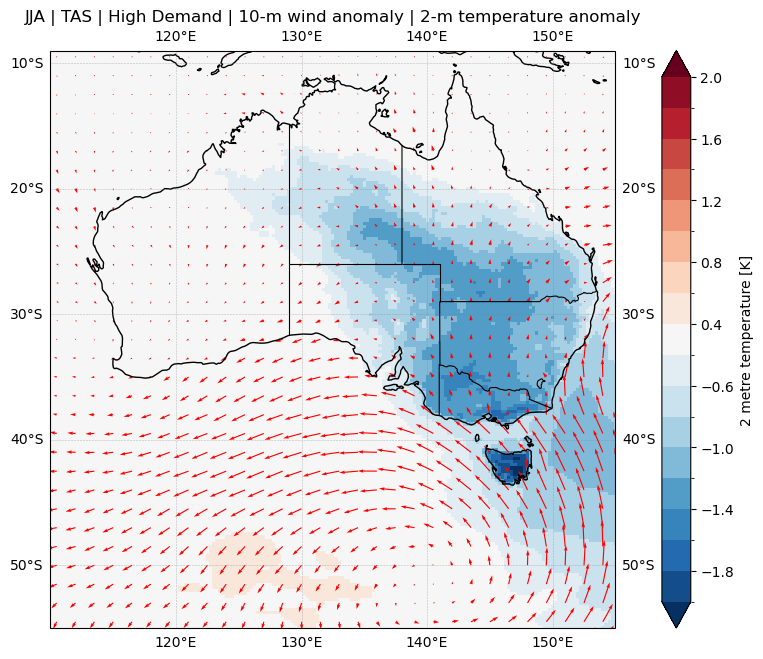

In [12]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(12, 7.5),
    dpi=100,
    facecolor="w",
    subplot_kw={"projection": mapcrs},
)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="k", lw=1)
ax.set_extent([110, 155, -55, -9], crs=datacrs)
states_shp = shapereader.natural_earth(
    resolution="50m",
    category="cultural",
    name="admin_1_states_provinces_lines",
)

states = cfeature.ShapelyFeature(
    shapereader.Reader(states_shp).geometries(),
    ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
)

ax.add_feature(states)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)

# tempeature
clevs = np.concatenate([np.arange(-2, -.4+.2, .2), np.arange(.4, 2.2, .2)])
ds_compo['tmean'].plot(ax=ax, levels=clevs, cmap='RdBu_r', transform=datacrs, extend='both')

# wind field
u = ds_compo['u10'].values
v = ds_compo['v10'].values
lats = ds_compo['latitude'].values
lons = ds_compo['longitude'].values

skip = 6
q = ax.quiver(
    lons[::skip],lats[::skip],
    u[::skip, ::skip],v[::skip, ::skip],
    transform=datacrs,color='r',width=0.002,
)
ax.set_title(f'{season} | {state} | High Demand | 10-m wind anomaly | 2-m temperature anomaly')
plt.show()